In [6]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix

In [4]:

# Run the inspection
weightdir = "/global/cfs/cdirs/wcm_shr/DP-SCREAM/remap"

weightfile = "DPSCREAM_RCE_dx1km_600x600km_to_PINACLES_YX_dx1km_600x600km_conserve.nc"

weight_filename = f"{weightdir}/{weightfile}"

In [5]:
print(f"Opening {weight_filename}...\n")
ds = nc.Dataset(weight_filename, 'r')

# Extract the sparse matrix arrays
# Note: ESMF uses 1-based indexing for Fortran compatibility. 
# We subtract 1 to make them 0-based for Python/C arrays.
S = ds.variables['S'][:]
row = ds.variables['row'][:] - 1
col = ds.variables['col'][:] - 1

num_links = len(S)
print(f"Total non-zero weights (links): {num_links}")

# Look at the first 5 connections
print("\nFirst 5 connections in the sparse matrix:")
print("--------------------------------------------------")
print("Dest Cell (row) | Source Cell (col) | Weight (S)")
print("--------------------------------------------------")
for i in range(20):
    print(f"{row[i]:<15} | {col[i]:<17} | {S[i]:.6f}")

# --- ADVANCED: Look at a specific Destination Cell ---
# Let's find all source cells contributing to Destination Cell #100
target_dest_cell = 1000

# Find indices in 'row' where the destination is 100
# (np.where returns a tuple, we take the first element)
indices = np.where(row == target_dest_cell)[0]

print(f"\nSource cells contributing to Destination Cell {target_dest_cell}:")
total_weight = 0.0
for idx in indices:
    source_cell = col[idx]
    weight = S[idx]
    total_weight += weight
    print(f"  <- Source Cell {source_cell}: adds {weight:.4f} of its value")
    
print(f"Total weight for Dest Cell {target_dest_cell}: {total_weight:.4f}")


Opening /global/cfs/cdirs/wcm_shr/DP-SCREAM/remap/DPSCREAM_RCE_dx1km_600x600km_to_PINACLES_YX_dx1km_600x600km_conserve.nc...

Total non-zero weights (links): 813600

First 5 connections in the sparse matrix:
--------------------------------------------------
Dest Cell (row) | Source Cell (col) | Weight (S)
--------------------------------------------------
0               | 0                 | 0.999989
1               | 2                 | 0.500012
1               | 0                 | 0.499988
2               | 800               | 0.000007
2               | 2                 | 0.999993
3               | 800               | 1.000000
4               | 802               | 0.500004
4               | 800               | 0.499996
5               | 1600              | 0.000000
5               | 802               | 1.000000
6               | 1600              | 0.999999
6               | 802               | 0.000001
7               | 1602              | 0.499996
7               | 1600        

Matrix Shape: 360000 (Dest) x 160000 (Source)
Non-zero elements: 813600
Generating spy plot...


<Figure size 1000x1000 with 0 Axes>

Text(0.5, 1.0, 'Sparsity Pattern of Regridding Weights\n360000 x 160000')

Text(0.5, 0, 'Source Grid Index (col)')

Text(0, 0.5, 'Destination Grid Index (row)')

Saved visualization to weight_matrix_sparsity.png


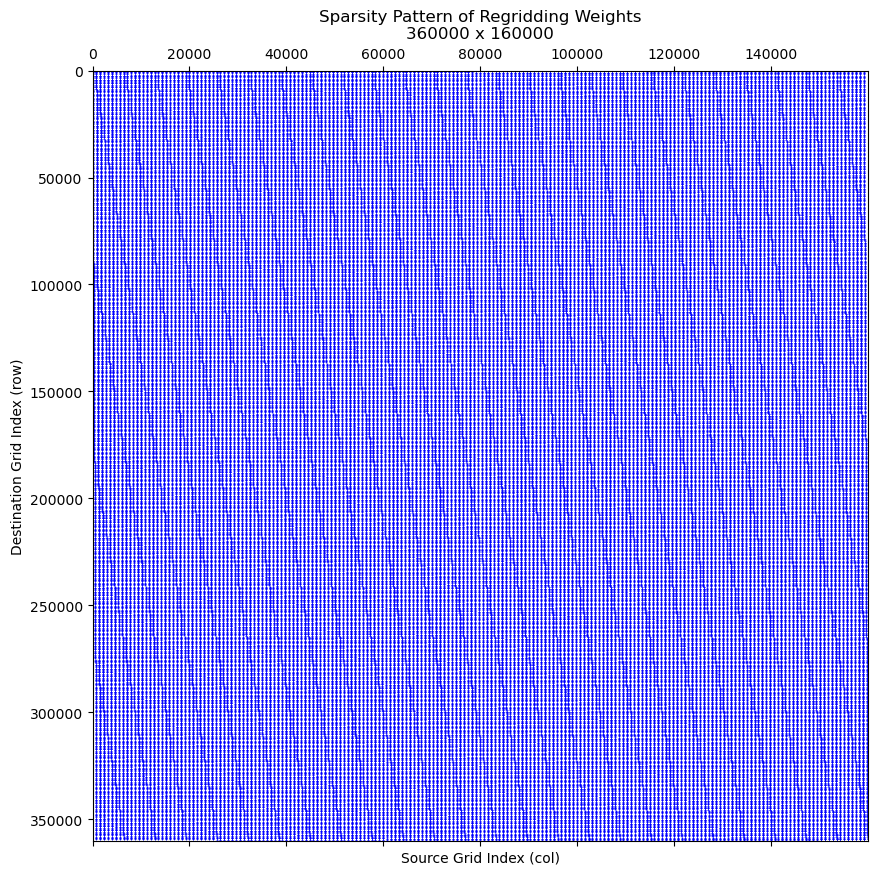

In [7]:
# Determine matrix dimensions
# If the file has explicit n_a and n_b dimensions, you can read them.
# Otherwise, the safest way is to find the maximum index used.
num_dst = ds.dimensions['n_b'].size if 'n_b' in ds.dimensions else row.max() + 1
num_src = ds.dimensions['n_a'].size if 'n_a' in ds.dimensions else col.max() + 1

print(f"Matrix Shape: {num_dst} (Dest) x {num_src} (Source)")
print(f"Non-zero elements: {len(S)}")

# 2. Reconstruct the Sparse Matrix
# We use COO (Coordinate) format which directly maps to S, row, col
W = coo_matrix((S, (row, col)), shape=(num_dst, num_src))

# 3. Visualize the Sparsity Pattern
print("Generating spy plot...")
plt.figure(figsize=(10, 10))

# plt.spy is specifically designed for sparse matrices.
# 'markersize' needs to be very small for large climate grids
# 'precision=0' means plot any value greater than 0
plt.spy(W, markersize=0.1, precision=0, color='blue', aspect='auto')

plt.title(f"Sparsity Pattern of Regridding Weights\n{num_dst} x {num_src}")
plt.xlabel("Source Grid Index (col)")
plt.ylabel("Destination Grid Index (row)")

# Optional: Save it to a high-resolution image instead of trying to render 
# a massive interactive window over an SSH/X11 connection.
out_img = "weight_matrix_sparsity.png"
plt.savefig(out_img, dpi=300, bbox_inches='tight')
print(f"Saved visualization to {out_img}")

plt.show()

In [ ]:

ds.close()
